In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
ds_filtered = xr.open_dataset("/Users/lb962/Documents/GitHub/ESL_stats/data/processed/selected_filter_stations.nc")

In [3]:
import numpy as np
import xarray as xr

time_dim = "valid_time"
station_dim = "station"
var = "sea_level"

# 1) annual means per station
annual = ds_filtered[var].resample({time_dim: "YS"}).mean()

# 2) numeric years since first annual sample, centered for stability
t = xr.DataArray(
    (annual[time_dim] - annual[time_dim].isel({time_dim: 0})) / np.timedelta64(1, "D") / 365.25,
    dims=time_dim,
    coords={time_dim: annual[time_dim]},
)
t = t - t.mean(time_dim)

# 3) mask finite data
y = annual
mask = np.isfinite(y)

# 4) station-wise OLS slope/intercept using xarray algebra
t_masked = t.where(mask)
t_mean = t_masked.mean(time_dim)
y_mean = y.where(mask).mean(time_dim)

cov_ty = ((t - t_mean) * (y - y_mean)).where(mask).sum(time_dim)
var_t = ((t - t_mean) ** 2).where(mask).sum(time_dim)

slope = cov_ty / var_t
intercept = y_mean - slope * t_mean

# 5) evaluate trend on full original time axis
t_full = xr.DataArray(
    (ds_filtered[time_dim] - annual[time_dim].isel({time_dim: 0})) / np.timedelta64(1, "D") / 365.25,
    dims=time_dim,
    coords={time_dim: ds_filtered[time_dim]},
)
t_full = t_full - t.mean(time_dim)

trend_full = slope * t_full + intercept

# 6) save
ds_filtered[f"{var}_annual_mean"] = annual
ds_filtered[f"{var}_station_trend_per_year"] = slope
ds_filtered[f"{var}_station_intercept"] = intercept
ds_filtered[f"{var}_annual_linear_trend"] = trend_full
ds_filtered[f"{var}_annual_detrended"] = ds_filtered[var] - trend_full

In [4]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st
import pandas as pd
from sklearn.cluster import KMeans

# --- config ---
TARGET_VAR = 'sea_level_annual_detrended'
N_STATIONS = 295
CSV_OUT = "gev_fit_scores_twl.csv"
N_CLUSTERS = 3

if TARGET_VAR not in ds_filtered.data_vars:
    for v in ds_filtered.data_vars:
        if np.issubdtype(ds_filtered[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}' (first numeric data variable).")
            break
    else:
        raise ValueError("No numeric data variable found to fit.")

def _meta_for_station(i):
    lat = None
    lon = None
    try:
        lat = float(ds_filtered["station_latitude"].sel(station=i))
        lon = float(ds_filtered["station_longitude"].sel(station=i))
    except Exception:
        try:
            lat = float(ds_filtered["latitude"])
            lon = float(ds_filtered["longitude"])
        except Exception:
            pass
    return lat, lon

def _time_dim(da):
    candidates = [d for d in da.dims if d not in ("station", "stations")]
    if not candidates:
        raise ValueError("Could not infer time dimension.")
    return candidates[0]

def kuiper_statistic(x, cdf_func):
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / n
    F_mod = cdf_func(x)
    D_plus = np.max(F_emp - F_mod)
    D_minus = np.max(F_mod - (i - 1) / n)
    return D_plus + D_minus

def r2_cdf_fit(x, cdf_func):
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / (n + 1.0)
    F_mod = cdf_func(x)
    ss_res = np.sum((F_emp - F_mod) ** 2)
    ss_tot = np.sum((F_emp - np.mean(F_emp)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot

stations = np.array(ds_filtered["station"].values)[:N_STATIONS]

results = []

for s in stations:
    try:
        da = ds_filtered[TARGET_VAR].sel(station=s)
    except Exception:
        print(f"Skipping station {s}: not present in ds_filtered.")
        continue

    try:
        tdim = _time_dim(da)
    except Exception as e:
        print(f"Skipping station {s}: could not infer time dimension ({e}).")
        continue

    da = da.where(np.isfinite(da), drop=True)

    if da.size < 10:
        print(f"Skipping station {s}: not enough data after cleaning.")
        continue

    try:
        da_bi = da.resample({tdim: "2M"}).max()
    except Exception as e:
        print(f"Skipping station {s}: resample failed ({e}).")
        continue

    x = da_bi.values.ravel()
    x = x[np.isfinite(x)]

    if x.size < 5:
        print(f"Skipping station {s}: not enough bimonthly maxima ({x.size}).")
        continue

    try:
        gev_params = st.genextreme.fit(x)
        c, loc, scale = gev_params
    except Exception as e:
        print(f"Skipping station {s}: GEV fit failed ({e}).")
        continue

    def gev_cdf(z):
        return st.genextreme.cdf(z, c, loc=loc, scale=scale)

    try:
        ks_stat, ks_p = st.kstest(x, "genextreme", args=gev_params)
        kuiper = kuiper_statistic(x, gev_cdf)
        r2 = r2_cdf_fit(x, gev_cdf)
    except Exception as e:
        print(f"Skipping station {s}: GOF calculation failed ({e}).")
        continue

    lat, lon = _meta_for_station(s)

    results.append({
        "station": int(s),
        "lat": lat,
        "lon": lon,
        "n_blocks": int(x.size),
        "gev_c": c,
        "gev_loc": loc,
        "gev_scale": scale,
        "ks_stat": ks_stat,
        "ks_pvalue": ks_p,
        "kuiper": kuiper,
        "r2_cdf": r2,
    })

df = pd.DataFrame(results)

if df.empty:
    raise RuntimeError("No stations were successfully fitted. Check your data and config.")

df.to_csv(CSV_OUT, index=False)
print(f"Saved GEV fit parameters and scores to: {CSV_OUT}")

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

Saved GEV fit parameters and scores to: gev_fit_scores_twl.csv


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


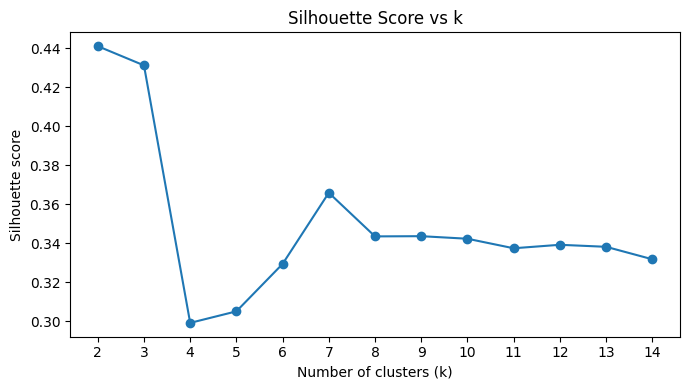

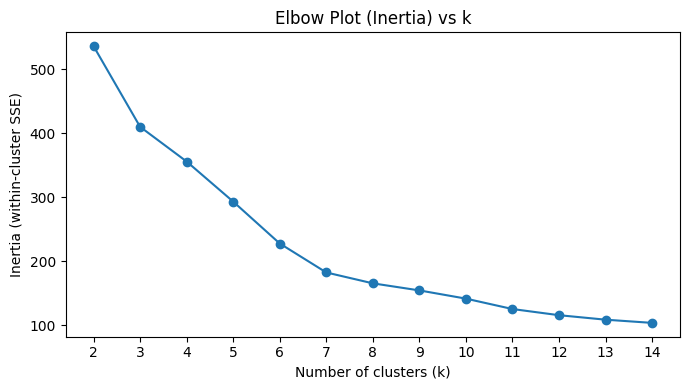

Best k by silhouette: 2
k= 2  silhouette=0.4411  inertia=536.26
k= 3  silhouette=0.4312  inertia=410.18
k= 4  silhouette=0.2992  inertia=355.96
k= 5  silhouette=0.3051  inertia=293.32
k= 6  silhouette=0.3294  inertia=227.86
k= 7  silhouette=0.3659  inertia=182.60
k= 8  silhouette=0.3435  inertia=165.60
k= 9  silhouette=0.3437  inertia=154.55
k=10  silhouette=0.3423  inertia=141.71
k=11  silhouette=0.3375  inertia=125.44
k=12  silhouette=0.3392  inertia=115.82
k=13  silhouette=0.3382  inertia=108.80
k=14  silhouette=0.3318  inertia=103.79


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1) Select GEV parameter features
feat_cols = ["gev_c", "gev_loc", "gev_scale"]
Xdf = df[feat_cols].apply(pd.to_numeric, errors="coerce")

# 2) Basic cleaning: drop rows with missing params, ensure valid scale
Xdf = Xdf.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")
Xdf = Xdf[Xdf["gev_scale"] > 0]  # scale must be positive

# Align df to Xdf rows
dfc = df.loc[Xdf.index].copy()

# 3) Light stabilization: log-transform scale (often highly skewed)
Xdf = Xdf.copy()
Xdf["gev_scale"] = np.log(Xdf["gev_scale"])

# 4) Standardize
scaler = StandardScaler()
Xs = scaler.fit_transform(Xdf.to_numpy(dtype=float))

k_range = range(2, 15)  # adjust upper bound if you want
sil_scores = []
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels = km.fit_predict(Xs)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Xs, labels))

# -----------------------------
# 1) Silhouette score plot
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), sil_scores, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs k")
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Elbow plot (inertia)
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Plot (Inertia) vs k")
plt.tight_layout()
plt.show()

# -----------------------------
# Optional: choose best k by silhouette
# -----------------------------
best_k_sil = list(k_range)[int(np.argmax(sil_scores))]
print("Best k by silhouette:", best_k_sil)

# Optional: print table for logging
for k, s, iner in zip(k_range, sil_scores, inertias):
    print(f"k={k:2d}  silhouette={s:.4f}  inertia={iner:.2f}")


In [19]:
# 6) Fit final KMeans
best_k = 7
km = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
labels = km.fit_predict(Xs)

# 7) Attach cluster labels back to df
dfc["cluster"] = labels + 1

# count stations per cluster
cluster_sizes = dfc["cluster"].value_counts()

# keep only clusters with >1 station
valid_clusters = cluster_sizes[cluster_sizes > 1].index

dfc = dfc[dfc["cluster"].isin(valid_clusters)].copy()

# 8) Save clustered table
CSV_OUT_CLUSTERED = CSV_OUT.replace(".csv", f"_kmeans_gev_k{best_k}.csv")
dfc.to_csv(CSV_OUT_CLUSTERED, index=False)
print(f"Saved clustered GEV parameters to: {CSV_OUT_CLUSTERED}")

# 9) Quick cluster summaries (in original parameter units)
summary = (
    dfc.groupby("cluster")[feat_cols + ["n_blocks", "ks_stat", "kuiper", "r2_cdf"]]
       .agg(["count", "mean", "median", "std"])
)

Saved clustered GEV parameters to: gev_fit_scores_twl_kmeans_gev_k7.csv


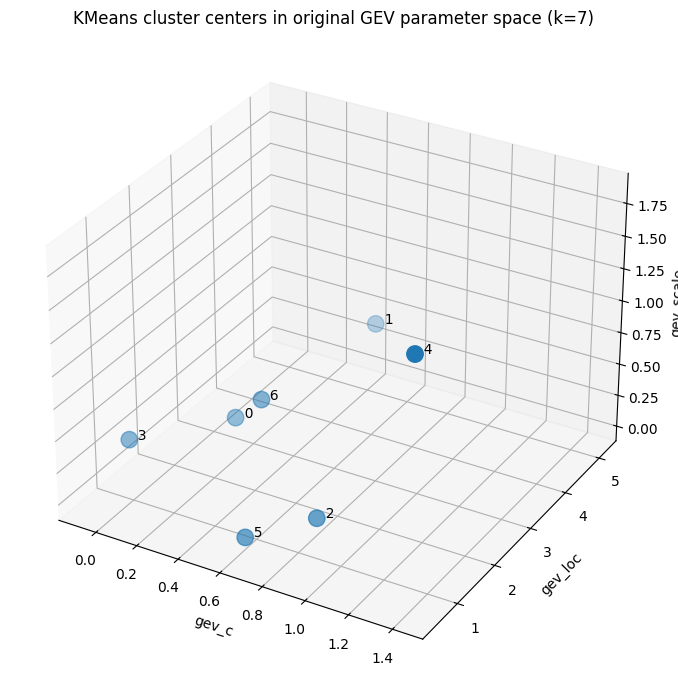

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Feature names (same order as used for fitting)
feat_cols = ["gev_c", "gev_loc", "gev_scale"]

# --------------------------------------------------
# 1. Get cluster centers in standardized space
# --------------------------------------------------
centers_std = km.cluster_centers_  # shape (k, 3)

# --------------------------------------------------
# 2. Invert standardization
# --------------------------------------------------
centers_unscaled = scaler.inverse_transform(centers_std)

# --------------------------------------------------
# 3. Undo log-transform on gev_scale
# --------------------------------------------------
centers_unscaled = centers_unscaled.copy()
centers_unscaled[:, 2] = np.exp(centers_unscaled[:, 2])

# --------------------------------------------------
# 4. Plot in ORIGINAL PARAMETER SPACE
# --------------------------------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    centers_unscaled[:, 0],
    centers_unscaled[:, 1],
    centers_unscaled[:, 2],
    s=140,
    marker="o",
    depthshade=True,
)

# Label each cluster center
for i in range(centers_unscaled.shape[0]):
    ax.text(
        centers_unscaled[i, 0],
        centers_unscaled[i, 1],
        centers_unscaled[i, 2],
        f"  {i}",
        fontsize=10,
    )

ax.set_xlabel("gev_c")
ax.set_ylabel("gev_loc")
ax.set_zlabel("gev_scale")
ax.set_title(f"KMeans cluster centers in original GEV parameter space (k={best_k})")

plt.tight_layout()
plt.show()


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_34768/2708620325.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", k) if k <= 20 else cm.get_cmap("gist_ncar", k)


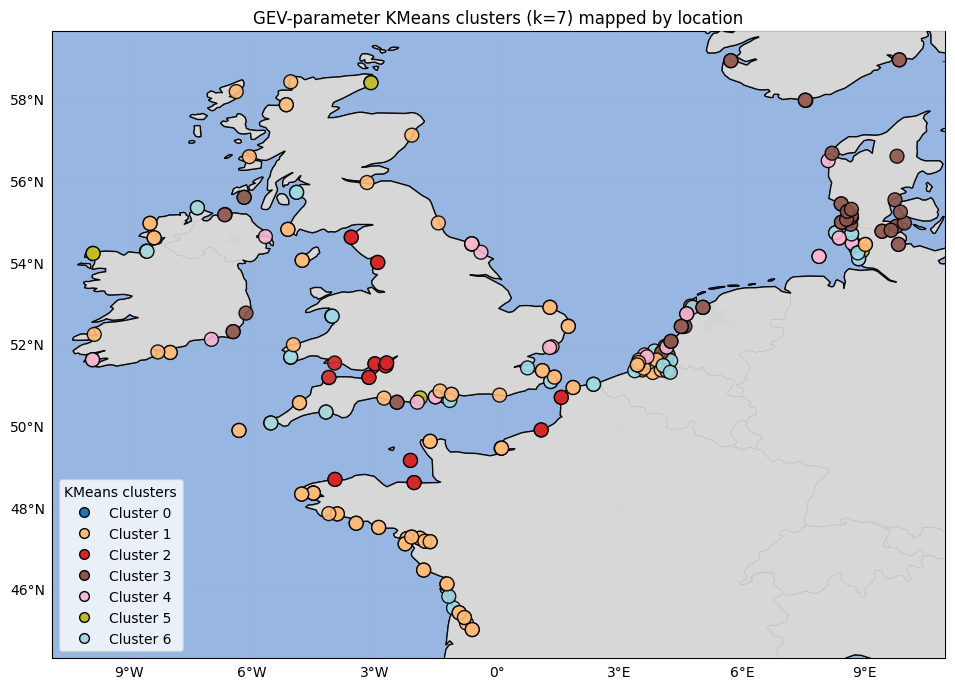

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# dfc must contain: lon, lat, cluster
# best_k is the number of clusters
assert {"lon", "lat", "cluster"}.issubset(dfc.columns)

# Ensure numeric lon/lat and drop missing
plotdf = dfc[["lon", "lat", "cluster"]].copy()

# 7) Attach cluster labels back to df
plotdf["cluster"] = labels + 1

# count stations per cluster
cluster_sizes = plotdf["cluster"].value_counts()

# keep only clusters with >1 station
valid_clusters = cluster_sizes[cluster_sizes > 1].index

plotdf= plotdf[plotdf["cluster"].isin(valid_clusters)].copy()

plotdf["lon"] = pd.to_numeric(plotdf["lon"], errors="coerce")
plotdf["lat"] = pd.to_numeric(plotdf["lat"], errors="coerce")
plotdf["cluster"] = pd.to_numeric(plotdf["cluster"], errors="coerce")
plotdf = plotdf.replace([np.inf, -np.inf], np.nan).dropna()

# If best_k not in scope, infer from data
k = int(plotdf["cluster"].nunique())

# --- Map setup ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

# Set extent with padding (optional but usually helpful)
lon_min, lon_max = plotdf["lon"].min(), plotdf["lon"].max()
lat_min, lat_max = plotdf["lat"].min(), plotdf["lat"].max()

pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent(
    [lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat],
    crs=ccrs.PlateCarree()
)

# Base features
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)

# Categorical colors for clusters
cmap = cm.get_cmap("tab20", k) if k <= 20 else cm.get_cmap("gist_ncar", k)
norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, k + 0.5, 1), ncolors=k)


# Land on top (so land masks points if you prefer). Adjust alpha as needed.
land = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", facecolor="lightgray", edgecolor="black"
)
ax.add_feature(land, alpha=0.9, zorder=5)

# Optional: gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Legend (categorical)
# Build custom legend handles
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="",
               markersize=7, markerfacecolor=cmap(i), markeredgecolor="k",
               label=f"Cluster {i}")
    for i in range(k)
]

# Scatter points (clusters)
sc = ax.scatter(
    plotdf["lon"].values,
    plotdf["lat"].values,
    c=plotdf["cluster"].values,
    cmap=cmap,
    norm=norm,
    s=100,
    zorder=40,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    edgecolors='black')
ax.set_title(f"GEV-parameter KMeans clusters (k={k}) mapped by location")
ax.legend(handles=handles, title="KMeans clusters", loc="lower left", frameon=True)
plt.tight_layout()
plt.show()


In [26]:
dfc.to_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/TWL_GEV_7_msl.csv")